# Import Library


In [2]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Load Image

In [3]:
image = Image.open("buah.jpg")
image_array = np.array(image)

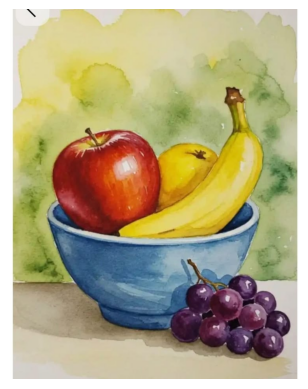

In [4]:
plt.imshow(image_array)
plt.axis("off")
plt.show()

# KMEANS

In [5]:
def kmeans_segmentation(image:np.ndarray,k:int,max_iter:int=100,tol:float=1e-4,random_seed:int=42):
    """
    Segment an image using K-Means Clustering based on pixel color (RGB).

    Iteratively assigns each pixel to the nearest cluster centroid (by Euclidean
    distance in RGB space), then updates centroids as the mean of assigned pixels.
    Stops when centroids converge or max_iter is reached.

    Parameters
    ----------
    image : np.ndarray
        Input image as a NumPy array of shape (H, W, 3) with dtype uint8 (R, G, B).
    k : int
        Number of clusters (segments). Default is 3.
    max_iter : int
        Maximum number of iterations. Default is 100.
    tol : float
        Convergence tolerance — stops if centroid shift is below this value. Default is 1e-4.
    random_seed : int
        Seed for reproducible centroid initialization. Default is 42.

    Returns
    -------
    segmented_image : np.ndarray
        Image of shape (H, W, 3) where each pixel is replaced by its cluster's
        centroid color (uint8).
    labels : np.ndarray
        2D array of shape (H, W) with integer cluster assignments [0, k-1].

    Example
    -------
    >>> img = np.random.randint(0, 256, (100, 100, 3), dtype=np.uint8)
    >>> segmented, labels = kmeans_segmentation(img, k=4)
    """
    
    H,W,C = image.shape
    pixels = image.reshape(-1,C).astype(np.float64)
    N = pixels.shape[0]
    
    # --- Initialize centroids by random pixel sampling (K-Means++) style ---
    rng = np.random.default_rng(random_seed)
    indices = rng.choice(N,size=k,replace=False)
    centroids = pixels[indices].copy()
    
    labels = np.zeros(N,dtype=np.int32)
    for iteration in range(max_iter):
        # --- Assignment step: assign each pixel to nearest centroid ---
        # Compute squared Euclidean distances: (N, k)
        diff = pixels[:,np.newaxis,:] - centroids[np.newaxis,:,:] # (N, k, 3)
        distances = np.sum(diff ** 2, axis=2)  # (N, k)
        new_labels = np.argmin(distances, axis=1)  # (N,)
        
        # --- Update step: recompute centroids ---
        new_centroids = np.zeros_like(centroids)
        for j in range(k):
            mask = new_labels == j
            if mask.sum() > 0:
                new_centroids[j] = pixels[mask].mean(axis=0)
            else:
                # Handle empty cluster: reinitialize to a random pixel
                new_centroids[j] = pixels[rng.integers(0, N)]
        
        # --- Convergence check ---
        centroid_shift = np.linalg.norm(new_centroids - centroids)
        centroids = new_centroids
        labels = new_labels
        
        if centroid_shift < tol:
            print(f"[K-Means] Converged at iteration {iteration + 1} (shift={centroid_shift:.6f})")
            break
    else:
        print(f"[K-Means] Reached max_iter={max_iter} without full convergence.")
        
    # --- Reconstruct segmented image using centroid colors ---
    segmented_pixels = centroids[labels]  # (N, 3)
    segmented_image = np.clip(segmented_pixels, 0, 255).astype(np.uint8).reshape(H, W, C)
    labels_2d = labels.reshape(H, W)

    return segmented_image, labels_2d

In [6]:
# apply fungsi
segmented,labels = kmeans_segmentation(image_array,5)

[K-Means] Converged at iteration 26 (shift=0.000000)


In [7]:
# cel label setiap pixel
labels

array([[3, 3, 3, ..., 3, 3, 3],
       [3, 3, 3, ..., 3, 3, 3],
       [3, 3, 3, ..., 3, 3, 3],
       ...,
       [3, 3, 3, ..., 3, 3, 3],
       [3, 3, 3, ..., 3, 3, 3],
       [3, 3, 3, ..., 3, 3, 3]], shape=(943, 735))

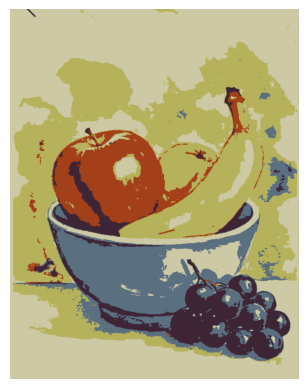

In [8]:
# visualisasi image
plt.imshow(segmented)
plt.axis("off")
plt.show()

# Graph Cut

In [ ]:
def graph_cut_segmentation(
    image: np.ndarray,
    foreground_seeds: list[tuple[int, int]],
    background_seeds: list[tuple[int, int]],
    sigma: float = 30.0,
    lambda_weight: float = 5.0,
    max_iter: int = 100
) -> tuple[np.ndarray, np.ndarray]:
    """
    Segment an image into foreground and background using an iterative Graph Cut
    approach (approximated via min-cut energy optimization with push-relabel-style
    iterations — implemented from scratch in NumPy without external graph libraries).

    The energy function minimized is:
        E(f) = Σ D(p, f_p)  +  λ · Σ V(p, q, f_p, f_q)
    where:
        - D(p, label): data term — how well pixel p fits foreground/background
          based on seed color histograms (negative log-likelihood).
        - V(p, q): smoothness term — boundary penalty between neighboring pixels,
          weighted by color similarity (Gaussian kernel on intensity difference).

    This implementation uses iterative belief-propagation-style label refinement
    (alpha-expansion approximation) to minimize the energy without requiring
    external max-flow libraries.

    Parameters
    ----------
    image : np.ndarray
        Input image as a NumPy array of shape (H, W, 3), dtype uint8 (R, G, B).
    foreground_seeds : list of (row, col) tuples
        Pixel coordinates marked as foreground (object).
    background_seeds : list of (row, col) tuples
        Pixel coordinates marked as background.
    sigma : float
        Controls sensitivity of the boundary term to color differences.
        Higher = smoother boundaries. Default is 30.0.
    lambda_weight : float
        Weight of the smoothness term relative to the data term.
        Higher = more spatially consistent (smoother) segmentation. Default is 5.0.
    max_iter : int
        Maximum number of label-update iterations. Default is 100.

    Returns
    -------
    mask : np.ndarray
        Binary mask of shape (H, W), dtype uint8. 1 = foreground, 0 = background.
    overlay : np.ndarray
        Original image overlaid with a semi-transparent green foreground mask,
        shape (H, W, 3), dtype uint8. Useful for visual verification.

    Notes
    -----
    - Seeds must not be empty. Provide at least one foreground and one background seed.
    - For best results, seeds should be representative of each region's color.
    - This is an approximate graph cut; for exact min-cut, use libraries like PyMaxflow.

    Example
    -------
    >>> img = np.random.randint(0, 256, (100, 100, 3), dtype=np.uint8)
    >>> fg_seeds = [(20, 20), (25, 30)]
    >>> bg_seeds = [(20, 20), (25, 30)]
    >>> mask, overlay = graph_cut_segmentation(img, fg_seeds, bg_seeds)
    """
    if not foreground_seeds or not background_seeds:
        raise ValueError("Both foreground_seeds and background_seeds must be non-empty.")

    H, W, C = image.shape
    gray = image.mean(axis=2)  # (H, W) — grayscale for smoothness term

    # -------------------------------------------------------------------------
    # Step 1: Build color histograms from seeds (data term)
    # -------------------------------------------------------------------------
    def _collect_seed_colors(seeds: list[tuple[int, int]]) -> np.ndarray:
        """Collect RGB pixel values from seed coordinates."""
        return np.array([image[r, c] for r, c in seeds], dtype=np.float64)

    fg_colors = _collect_seed_colors(foreground_seeds)  # (Nfg, 3)
    bg_colors = _collect_seed_colors(background_seeds)  # (Nbg, 3)

    # Compute per-class mean and covariance for Gaussian color model
    fg_mean = fg_colors.mean(axis=0)  # (3,)
    bg_mean = bg_colors.mean(axis=0)  # (3,)

    def _gaussian_color_prob(pixels: np.ndarray, mean: np.ndarray, std: float = 40.0) -> np.ndarray:
        """
        Compute Gaussian probability of pixels belonging to a color class.
        pixels: (N, 3), mean: (3,) → returns (N,) probabilities
        """
        diff = pixels - mean  # (N, 3)
        dist2 = np.sum(diff ** 2, axis=1)  # (N,)
        return np.exp(-dist2 / (2 * std ** 2))

    pixels_flat = image.reshape(-1, 3).astype(np.float64)  # (N, 3)
    N = pixels_flat.shape[0]

    fg_prob = _gaussian_color_prob(pixels_flat, fg_mean) + 1e-10  # (N,)
    bg_prob = _gaussian_color_prob(pixels_flat, bg_mean) + 1e-10  # (N,)

    # Data cost: negative log-likelihood (lower = more likely)
    # cost_fg[i] = cost of labeling pixel i as foreground
    cost_fg = -np.log(fg_prob / (fg_prob + bg_prob)).reshape(H, W)   # (H, W)
    cost_bg = -np.log(bg_prob / (fg_prob + bg_prob)).reshape(H, W)   # (H, W)

    # -------------------------------------------------------------------------
    # Step 2: Compute boundary (smoothness) weights between 4-neighbors
    # -------------------------------------------------------------------------
    # V(p, q) = lambda * exp(-|I_p - I_q|^2 / (2*sigma^2))
    # Penalizes assigning different labels to similar-colored neighbors.

    def _boundary_weight(diff_map: np.ndarray) -> np.ndarray:
        return lambda_weight * np.exp(-(diff_map ** 2) / (2 * sigma ** 2))

    # Horizontal neighbors: p=(r,c), q=(r,c+1)
    h_diff = np.abs(gray[:, :-1] - gray[:, 1:])   # (H, W-1)
    w_h = _boundary_weight(h_diff)                  # (H, W-1)

    # Vertical neighbors: p=(r,c), q=(r+1,c)
    v_diff = np.abs(gray[:-1, :] - gray[1:, :])   # (H-1, W)
    w_v = _boundary_weight(v_diff)                  # (H-1, W)

    # -------------------------------------------------------------------------
    # Step 3: Initialize labels from seed constraints
    # -------------------------------------------------------------------------
    # 0 = background, 1 = foreground, -1 = unknown
    labels = np.full((H, W), -1, dtype=np.int8)
    for r, c in foreground_seeds:
        labels[r, c] = 1
    for r, c in background_seeds:
        labels[r, c] = 0

    # Initialize unknowns using data term argmin
    unknown_mask = labels == -1
    labels[unknown_mask] = (cost_fg[unknown_mask] < cost_bg[unknown_mask]).astype(np.int8)

    # -------------------------------------------------------------------------
    # Step 4: Iterative energy minimization (ICM — Iterated Conditional Modes)
    # -------------------------------------------------------------------------
    # At each step, flip label of each pixel if it reduces total energy.
    # Seed pixels are kept fixed.

    seed_mask = np.zeros((H, W), dtype=bool)
    for r, c in foreground_seeds:
        seed_mask[r, c] = True
    for r, c in background_seeds:
        seed_mask[r, c] = True

    def _compute_smoothness_cost(lbl: np.ndarray) -> np.ndarray:
        """Compute per-pixel smoothness cost contribution (4-connected)."""
        smooth = np.zeros((H, W), dtype=np.float64)

        # Horizontal
        diff_h = (lbl[:, :-1] != lbl[:, 1:]).astype(np.float64)
        smooth[:, :-1] += diff_h * w_h
        smooth[:, 1:] += diff_h * w_h

        # Vertical
        diff_v = (lbl[:-1, :] != lbl[1:, :]).astype(np.float64)
        smooth[:-1, :] += diff_v * w_v
        smooth[1:, :] += diff_v * w_v

        return smooth

    prev_energy = np.inf

    for iteration in range(max_iter):
        smooth_cost = _compute_smoothness_cost(labels)

        # Total cost for current label vs flipped label
        energy_current = np.where(labels == 1, cost_fg, cost_bg) + smooth_cost

        # Cost if we flip each pixel
        flipped = 1 - labels
        smooth_cost_flipped = _compute_smoothness_cost(flipped)
        energy_flipped = np.where(flipped == 1, cost_fg, cost_bg) + smooth_cost_flipped

        # Flip pixels where flipping reduces energy (excluding seeds)
        should_flip = (energy_flipped < energy_current) & (~seed_mask)
        labels[should_flip] = flipped[should_flip]

        total_energy = energy_current[~seed_mask].sum()
        delta = abs(prev_energy - total_energy)

        if delta < 1e-3:
            print(f"[Graph Cut] Converged at iteration {iteration + 1} (ΔE={delta:.6f})")
            break
        prev_energy = total_energy
    else:
        print(f"[Graph Cut] Reached max_iter={max_iter}.")

    # -------------------------------------------------------------------------
    # Step 5: Build output mask and overlay
    # -------------------------------------------------------------------------
    mask = labels.astype(np.uint8)  # 1=foreground, 0=background

    # Green overlay on foreground region
    overlay = image.copy()
    fg_region = mask == 1
    overlay[fg_region, 0] = (overlay[fg_region, 0] * 0.5).astype(np.uint8)        # R
    overlay[fg_region, 1] = np.clip(overlay[fg_region, 1] * 0.5 + 127, 0, 255).astype(np.uint8)  # G
    overlay[fg_region, 2] = (overlay[fg_region, 2] * 0.5).astype(np.uint8)        # B

    return mask, overlay

In [23]:
#apply fungsion
mask,overlay = graph_cut_segmentation(image_array,[(20, 50), (25, 30)],[(20, 20), (25, 30)])

[Graph Cut] Converged at iteration 2 (ΔE=0.000000)


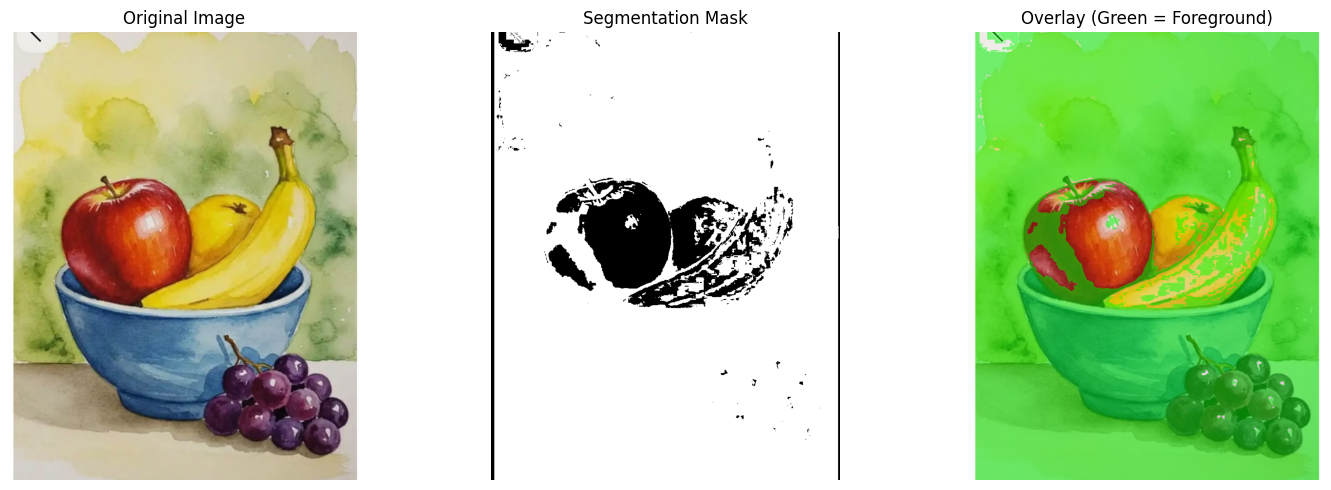

In [24]:
# Visualisasi 3 panel sekaligus
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(mask, cmap="gray")   # putih = foreground, hitam = background
axes[1].set_title("Segmentation Mask")
axes[1].axis("off")

axes[2].imshow(overlay)
axes[2].set_title("Overlay (Green = Foreground)")
axes[2].axis("off")

plt.tight_layout()
plt.savefig("hasil_segmentasi.png", dpi=150)
plt.show()